# Learning Sano's ribbon energy from the midpoint height alone

The control notebooks (`neural_control_sano*.ipynb`) learn the **boundary path** for a known energy. Here we flip the problem: the boundary paths are known, and a neural network learns the **constitutive law** of the ribbon.

The ground truth is a ribbon with Sano's regularized bend-twist coupling ($\zeta=0.1$):

$$e_\text{Sano} = e_\text{DER} + \tfrac12 EI_2\,\tau^2\,\underbrace{\frac{\tau^2}{\zeta^{-2}+\kappa_2^2}}_{f^*(\kappa_2,\tau)}.$$

**The data is one number per load step: the height of the middle node.** We drive the true ribbon along three clamp paths of $K=200$ steps and record only $z_\text{mid}$. No other node, twist angle, force or energy value is observed.

**Sparse observation, dense gradient.** Every prediction is an equilibrium $\nabla_x E_\theta(x_k,z_k)=0$ of the learned energy. The adjoint solve
$$\frac{d\mathcal L}{d\theta} = -\Big(\frac{\partial^2E_\theta}{\partial x\,\partial\theta}\Big)^{\!\top}\Big(\frac{\partial^2E_\theta}{\partial x^2}\Big)^{-1}\frac{\partial\mathcal L}{\partial x_k}$$
uses the full Hessian. So the one-hot sensitivity $\partial\mathcal L/\partial x_k=e_\text{mid}$ is spread over the strains of **every** triplet, and every triplet's energy density contributes to the gradient. `System.solve` gives this exactly (and through the warm-started path) with plain `jax.grad`, since the network is just an array in the `System` pytree.

In [1]:
import math, time
import equinox as eqx
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from dismech_jax import DER, Geometry, Material, Sano, make_rod

jax.config.update("jax_enable_x64", True)

## 1. Ribbon, clamps and load paths

This is the same ribbon and clamp actuation as `neural_control_sano.ipynb`. The left clamp is driven by end-shortening $p_x$, pitch $\beta$ and twist $\vartheta$. Each load path first tilts and twists the clamp, then compresses it, which keeps it on one stable branch.

* **Train:** twist $\pi$, $2\pi$ and $1.5\pi$ (the last with more compression).
* **Test (held out):** twist $2.5\pi$ with a different pitch and compression.

In [2]:
N, L = 41, 1.0
dl = L / (N - 1)
ZETA = 0.1
geom = Geometry(length=L, r0=1e-3, axs=3.14e-6, ixs1=7.85e-11, ixs2=7.85e-13, jxs=2e-12)  # EA=0.314, EI1=7.85e-6, EI2=7.85e-8
mat = Material(density=1200.0, youngs_rod=1e5, poisson_rod=0.3)

left = np.arange(7)  # node 0 (x,y,z,theta) and node 1 (x,y,z)
right = np.array([4 * (N - 2) + i for i in range(4)] + [4 * (N - 1) + i for i in range(3)])
fixed = jnp.asarray(np.concatenate([left, right]))

def build(model):
    return make_rod(geom, mat, N=N, fixed=fixed, gravity=jnp.zeros(3), model=model)

true_rod, aux0 = build(Sano.from_legacy(geom, mat, ZETA))   # ground truth (only used to make data)
der = DER.from_legacy(geom, mat)
der_rod, _ = build(der)                                     # baseline: no coupling

zpos = {int(d): i for i, d in enumerate(np.asarray(true_rod.idx_z))}
MID = 4 * (N // 2)  # first DOF of the middle node

def pose_to_zs(pose):
    px, pitch, tw = pose.T
    zs = jnp.tile(true_rod.z0, (pose.shape[0], 1))
    zs = zs.at[:, zpos[0]].set(px).at[:, zpos[3]].set(tw)
    return zs.at[:, zpos[4]].set(px + dl * jnp.cos(pitch)).at[:, zpos[6]].set(-dl * jnp.sin(pitch))

def ramp(t, a, b):
    return jnp.clip((t - a) / (b - a), 0.0, 1.0)

K = 200
tau_t = jnp.linspace(0, 1, K)
def schedule(px, pitch, twist):  # twist and tilt first, then compress
    return jnp.stack([px * ramp(tau_t, .5, 1), pitch * ramp(tau_t, 0, .5), twist * ramp(tau_t, 0, .5)], 1)

train = {"twist pi": (.2, .3, math.pi), "twist 2pi": (.2, .3, 2 * math.pi), "twist 1.5pi": (.3, .2, 1.5 * math.pi)}
test = {"twist 2.5pi (held out)": (.25, .25, 2.5 * math.pi)}
ZS_tr = jnp.stack([pose_to_zs(schedule(*v)) for v in train.values()])
ZS_te = jnp.stack([pose_to_zs(schedule(*v)) for v in test.values()])

def solve_paths(rod, ZS):
    # equilibrium path for every load path, batched
    X, res = jax.vmap(lambda zs: rod.solve(zs, aux0, iters=30))(ZS)
    return jax.vmap(rod.join)(X, ZS), res

## 2. The data: midpoint height only

`H_obs` has shape `(paths, K)`, one scalar per load step. This is everything the learner sees. The full true configurations are kept **only for evaluation**.

Plain DER (no coupling) already misses the midpoint by up to several centimeters. So the observation does carry information about the coupling.

In [3]:
Q_true_tr, res = solve_paths(true_rod, ZS_tr)
Q_true_te, _ = solve_paths(true_rod, ZS_te)
H_obs = Q_true_tr[..., MID + 2]                     # (3, 200): the only training data
h_scale = jnp.mean(H_obs ** 2)
print("data:", H_obs.shape, " max Newton residual of ground truth", float(res.max()))

Q_der_tr, _ = solve_paths(der_rod, ZS_tr)
for i, name in enumerate(train):
    print(f"{name:12s} plain DER misses the midpoint by up to {float(jnp.abs(Q_der_tr[i, :, MID + 2] - H_obs[i]).max()) * 100:.1f} cm")

data: (3, 200)  max Newton residual of ground truth 2.087114844387683e-10


twist pi     plain DER misses the midpoint by up to 6.5 cm
twist 2pi    plain DER misses the midpoint by up to 0.2 cm
twist 1.5pi  plain DER misses the midpoint by up to 6.8 cm


## 3. A neural energy density

We keep the DER stretch, bending and twist stiffnesses (assumed known from simple tests) and learn the correction to the easy-bend/twist coupling:

$$e_\theta = e_\text{DER} + \tfrac12 EI_2\,\tau^2\,f_\theta(\kappa_2^2,\tau^2),\qquad f_\theta = \operatorname{softplus}(\text{MLP}_\theta)\ \ge 0.$$

The structure only encodes symmetry ($\kappa_2\to-\kappa_2$, $\tau\to-\tau$) and that the correction is non-negative and vanishes in the untwisted state. The **shape** of $f$, including its $\kappa_2$-dependence and the regularization length, is left to the network (truth: $f^*=\tau^2/(\zeta^{-2}+\kappa_2^2)$). $f_\theta$ starts near 0, so training starts from plain DER.

`NeuralSano` is an ordinary `eqx.Module` model, the same kind as `DER` and `Sano`, so it plugs into `make_rod` unchanged.

In [4]:
class NeuralSano(DER):
    mlp: eqx.nn.MLP

    def coupling(self, kappa2, tau):
        return jax.nn.softplus(self.mlp(jnp.stack([kappa2 ** 2, tau ** 2]) / 100.0)[0])

    def __call__(self, del_strain):
        kappa2, tau = del_strain[3], del_strain[4]
        return super().__call__(del_strain) + 0.5 * self.K[3] * tau ** 2 * self.coupling(kappa2, tau)

mlp = eqx.nn.MLP(2, 1, 32, 2, activation=jnp.tanh, key=jax.random.PRNGKey(0))
mlp = eqx.tree_at(lambda m: m.layers[-1].weight, mlp, mlp.layers[-1].weight * 0.1)
mlp = eqx.tree_at(lambda m: m.layers[-1].bias, mlp, jnp.array([-4.0]))  # softplus(-4) ~ 0.02: start near DER
rod, _ = build(NeuralSano(K=der.K, mlp=mlp))

def with_mlp(m):
    return eqx.tree_at(lambda r: r.terms[0].model.mlp, rod, m)

def loss_fn(m):
    Q, res = solve_paths(with_mlp(m), ZS_tr)
    return jnp.mean((Q[..., MID + 2] - H_obs) ** 2) / h_scale, res   # midpoint height only

loss_and_grad = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn, has_aux=True))

## 4. Training (Adam, exact gradients through 600 equilibrium solves per step)

In [5]:
def adam_step(params, grads, state, lr=1e-2, b1=0.9, b2=0.999):
    m, v, t = state; t += 1
    m = jax.tree.map(lambda a, g: b1 * a + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda a, g: b2 * a + (1 - b2) * g * g, v, grads)
    step = jax.tree.map(lambda a, b: lr * (a / (1 - b1 ** t)) / (jnp.sqrt(b / (1 - b2 ** t)) + 1e-8), m, v)
    return jax.tree.map(lambda p, s: p - s, params, step), (m, v, t)

params, static = eqx.partition(mlp, eqx.is_inexact_array)
state = (jax.tree.map(jnp.zeros_like, params), jax.tree.map(jnp.zeros_like, params), 0)
history, t0 = [], time.time()
for it in range(300):
    (loss, res), grads = loss_and_grad(eqx.combine(params, static))
    params, state = adam_step(params, eqx.filter(grads, eqx.is_inexact_array), state)
    history.append(float(loss))
    if it % 25 == 0 or it == 299:
        print(f"iter {it:3d}  loss {float(loss):.3e}  max Newton residual {float(res.max()):.1e}  ({time.time() - t0:.0f}s)")
mlp = eqx.combine(params, static)
learned_rod = with_mlp(mlp)

iter   0  loss 1.327e-02  max Newton residual 5.7e-05  (11s)


iter  25  loss 6.717e-03  max Newton residual 3.4e-01  (113s)


iter  50  loss 5.625e-05  max Newton residual 3.4e-09  (247s)


iter  75  loss 1.468e-05  max Newton residual 6.1e-10  (382s)


iter 100  loss 1.350e-05  max Newton residual 7.4e-10  (500s)


...

iter 200  loss 9.240e-06  max Newton residual 5.1e-10  (1072s)


iter 225  loss 7.896e-06  max Newton residual 3.8e-10  (1227s)


iter 250  loss 6.328e-06  max Newton residual 2.7e-10  (1371s)


iter 275  loss 4.676e-06  max Newton residual 2.1e-10  (1494s)


iter 299  loss 3.387e-06  max Newton residual 1.8e-10  (1590s)


## 5. Results

**Evaluation on what the learner never saw:** the full 3D shapes of the training paths, and both the midpoint and the full shape on the held-out path.

In [6]:
Q_lrn_tr, _ = solve_paths(learned_rod, ZS_tr)
Q_lrn_te, res_te = solve_paths(learned_rod, ZS_te)
Q_der_te, _ = solve_paths(der_rod, ZS_te)

def node_err(Q, Qt):  # max node position error over the whole path, in cm
    P = lambda Q: jnp.stack([Q[..., 0::4], Q[..., 1::4], Q[..., 2::4]], -1)
    return 100 * jnp.linalg.norm(P(Q) - P(Qt), axis=-1).max(axis=(-1, -2))

print(f"{'path':24s} {'model':8s} {'max midpoint err':>17s} {'max node err (unseen)':>22s}")
for names, Qt, preds in [(train, Q_true_tr, {"DER": Q_der_tr, "learned": Q_lrn_tr}),
                         (test, Q_true_te, {"DER": Q_der_te, "learned": Q_lrn_te})]:
    for lab, Q in preds.items():
        dh = 100 * jnp.abs(Q[..., MID + 2] - Qt[..., MID + 2]).max(-1)
        ne = node_err(Q, Qt)
        for i, name in enumerate(names):
            print(f"{name:24s} {lab:8s} {float(dh[i]):14.2f} cm {float(ne[i]):19.2f} cm")
print("max Newton residual (learned, test):", float(res_te.max()))

path                     model     max midpoint err  max node err (unseen)


twist pi                 DER                6.54 cm                7.82 cm
twist 2pi                DER                0.24 cm                1.12 cm
twist 1.5pi              DER                6.85 cm               39.10 cm
twist pi                 learned            0.06 cm                0.10 cm
twist 2pi                learned            0.07 cm                0.19 cm
twist 1.5pi              learned            0.02 cm                0.11 cm


twist 2.5pi (held out)   DER                1.74 cm                2.66 cm
twist 2.5pi (held out)   learned            0.44 cm                0.62 cm
max Newton residual (learned, test): 9.612664125362862e-11


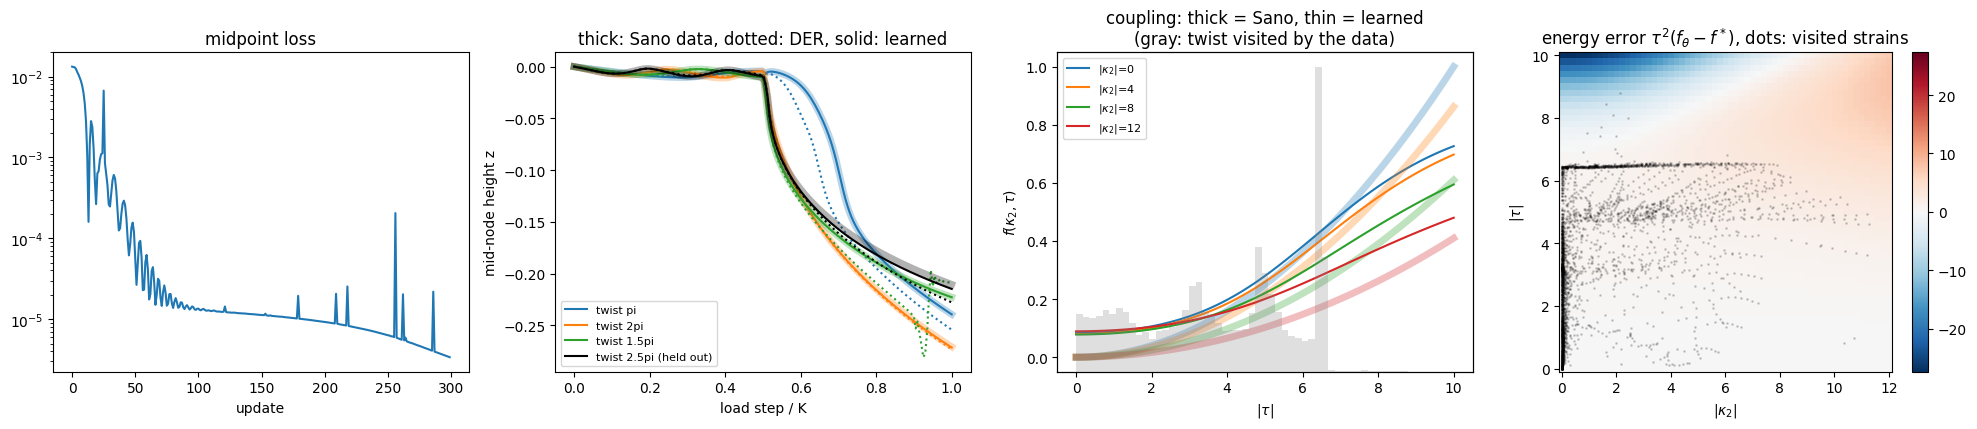

In [7]:
# strains (kappa2, tau) visited by the true ribbon on the training paths: where the data can inform f
st = true_rod.terms[0]
def strains(Q):
    def f(a, q):
        s = jax.vmap(lambda s_, ql, a_: s_.get_strain(ql, a_) - s_.bar_strain)(st.stencils, q[st.conn], a[0])
        return true_rod.update(a, *true_rod.split(q)), s
    return jax.lax.scan(f, aux0, Q)[1]
S_vis = np.concatenate([np.asarray(strains(Q)).reshape(-1, 5) for Q in Q_true_tr])
k2_vis, tau_vis = np.abs(S_vis[:, 3]), np.abs(S_vis[:, 4])

lm = learned_rod.terms[0].model
f_learned = jax.vmap(jax.vmap(lm.coupling))
f_true = lambda k2, t: t ** 2 / (1 / ZETA ** 2 + k2 ** 2)
cols = plt.cm.tab10.colors

fig, axs = plt.subplots(1, 4, figsize=(20, 4.4))
ax = axs[0]
ax.semilogy(history); ax.set_xlabel("update"); ax.set_title("midpoint loss")

ax = axs[1]
for i, name in enumerate(train):
    ax.plot(tau_t, H_obs[i], color=cols[i], lw=5, alpha=.3)
    ax.plot(tau_t, Q_der_tr[i, :, MID + 2], color=cols[i], ls=":")
    ax.plot(tau_t, Q_lrn_tr[i, :, MID + 2], color=cols[i], label=name)
ax.plot(tau_t, Q_true_te[0, :, MID + 2], color="k", lw=5, alpha=.3)
ax.plot(tau_t, Q_der_te[0, :, MID + 2], color="k", ls=":")
ax.plot(tau_t, Q_lrn_te[0, :, MID + 2], color="k", label=list(test)[0])
ax.set_xlabel("load step / K"); ax.set_ylabel("mid-node height z")
ax.set_title("thick: Sano data, dotted: DER, solid: learned"); ax.legend(fontsize=8)

ax = axs[2]
tg = jnp.linspace(0, 10, 101)
for j, k2 in enumerate([0.0, 4.0, 8.0, 12.0]):
    kk = jnp.full_like(tg, k2)
    ax.plot(tg, f_true(kk, tg), color=cols[j], lw=5, alpha=.3)
    ax.plot(tg, f_learned(kk[None], tg[None])[0], color=cols[j], label=f"$|\\kappa_2|$={k2:g}")
ax2 = ax.twinx(); ax2.hist(tau_vis, bins=50, color="gray", alpha=.25); ax2.set_yticks([])
ax.set_xlabel(r"$|\tau|$"); ax.set_ylabel(r"$f(\kappa_2,\tau)$")
ax.set_title("coupling: thick = Sano, thin = learned\n(gray: twist visited by the data)"); ax.legend(fontsize=8)

ax = axs[3]
kg, tgg = jnp.meshgrid(jnp.linspace(0, 12, 61), jnp.linspace(0, 10, 51))
err = (f_learned(kg, tgg) - f_true(kg, tgg)) * tgg ** 2   # energy density error / (EI2 / 2)
vm = float(jnp.abs(err).max())
im = ax.pcolormesh(kg, tgg, err, cmap="RdBu_r", vmin=-vm, vmax=vm)
ax.scatter(k2_vis[::7], tau_vis[::7], s=1, c="k", alpha=.15)
plt.colorbar(im, ax=ax); ax.set_xlabel(r"$|\kappa_2|$"); ax.set_ylabel(r"$|\tau|$")
ax.set_title(r"energy error $\tau^2(f_\theta-f^*)$, dots: visited strains")
plt.tight_layout(); plt.show()

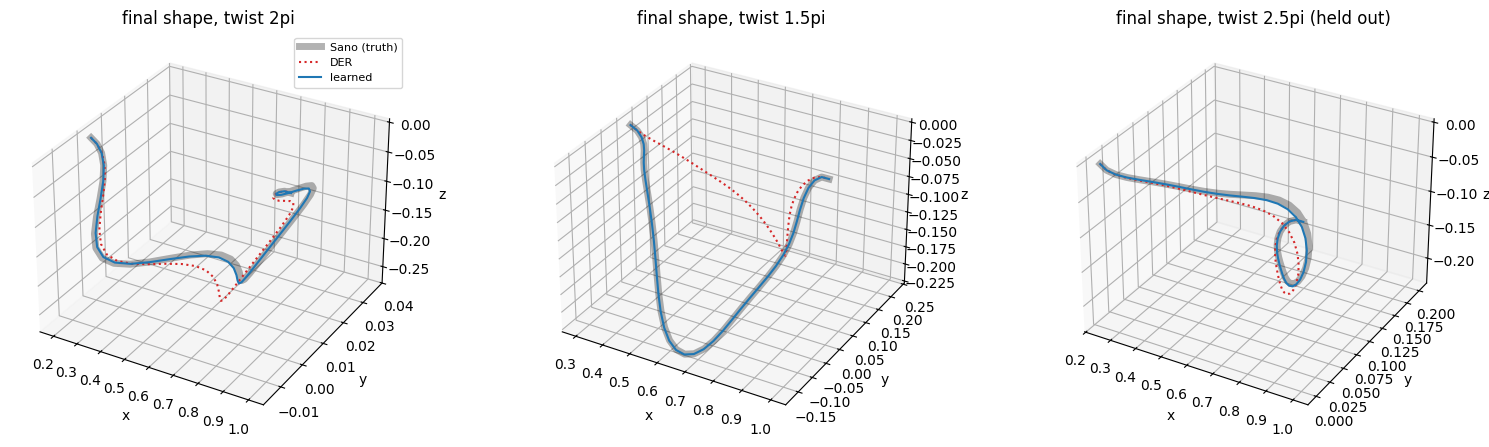

In [8]:
fig = plt.figure(figsize=(16, 4.5))
for i, (Qt, Qd, Ql, name) in enumerate([(Q_true_tr[1], Q_der_tr[1], Q_lrn_tr[1], list(train)[1]),
                                        (Q_true_tr[2], Q_der_tr[2], Q_lrn_tr[2], list(train)[2]),
                                        (Q_true_te[0], Q_der_te[0], Q_lrn_te[0], list(test)[0])]):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    for Q, lab, kw in [(Qt, "Sano (truth)", dict(color="k", lw=5, alpha=.3)),
                       (Qd, "DER", dict(color="tab:red", ls=":")),
                       (Ql, "learned", dict(color="tab:blue"))]:
        q = np.asarray(Q[-1]); ax.plot(q[0::4], q[1::4], q[2::4], label=lab, **kw)
    ax.set_title("final shape, " + name); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    if i == 0: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Notes

* **One scalar per step is enough here.** Fitting only $z_\text{mid}$ on three paths recovers the full 3D equilibrium shapes of those paths to millimeters, and cuts the held-out midpoint and shape errors about 4x compared with plain DER.
* **Why it works.** Each observation is an equilibrium of the whole ribbon. The adjoint solve with $\partial^2E_\theta/\partial x^2$ couples the observed DOF to every triplet, so all 39 energy densities along the ribbon get gradient signal from every scalar. This also holds over the warm-started path.
* **What is identified.** The learned $f_\theta$ matches $\tau^2/(\zeta^{-2}+\kappa_2^2)$ where the data lives (the dots in the error map). Near $\tau=0$, $f$ is multiplied by $\tau^2$ and is unobservable, so its value there is arbitrary but harmless. Beyond the visited twist range it extrapolates and starts to deviate. More varied load paths would widen the identified region.
* **Prior.** We assumed the DER stiffnesses are known and learned only the coupling, with symmetry and non-negativity built in. A fully free $e_\theta(\epsilon,\kappa_1,\kappa_2,\tau)$ has many more directions that leave the midpoint unchanged and would need richer observations.
* **Cost.** Each update solves 3 paths x 200 steps of Newton with the MLP inside the triplet Hessian, and backpropagates through all of them with one adjoint solve per step.